In [1]:
#imports and setups

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import shap
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

sns.set(style = "whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

RANDOM_STATE = 42

os.makedirs("images", exist_ok = True)

In [2]:
#load data & model artifacts

#paths
DATA_PATH  = "data/interim/df_preprocessed.csv"
MODEL_PATH = "models/artifacts/credit_model.joblib"
META_PATH  = "models/artifacts/metadata.json"

df = pd.read_csv(DATA_PATH)
pipe = joblib.load(MODEL_PATH)

with open(META_PATH, "r", encoding = "utf-8") as f:
    meta = json.load(f)

model_name = meta.get("model_name", "credit_model")
num_cols   = meta.get("num_cols", None)
cat_cols   = meta.get("cat_cols", None)
saved_thr  = meta.get("threshold", None)

print("Loaded model:", model_name)
print("Saved threshold:", saved_thr)

Loaded model: RandomForest
Saved threshold: 0.36


In [3]:
#rebuild train/test split

y = df["default"]
X = df.drop(columns = ["default", "id"], errors = "ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Default rate test:", y_test.mean().round(3))

Train: (24000, 36) Test: (6000, 36)
Default rate test: 0.221


In [4]:
#confusion matrix & metrics at operating threshold

def metrics_at_threshold(y_true, y_score, t):
    pred = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, (tn, fp, fn, tp)

proba = pipe.predict_proba(X_test)[:, 1]
thr = saved_thr if saved_thr is not None else 0.50

prec, rec, f1, (tn,fp,fn,tp) = metrics_at_threshold(y_test, proba, thr)
roc  = roc_auc_score(y_test, proba)
pr   = average_precision_score(y_test, proba)

print(f"Operating threshold: {thr:.2f}")
print(f"Precision = {prec:.3f} | Recall = {rec:.3f} | F1 = {f1:.3f}")
print(f"ROC-AUC = {roc:.3f} | PR-AUC = {pr:.3f}")
print("Confusion matrix [ [tn, fp], [fn, tp] ]:", [[tn, fp], [fn, tp]])

Operating threshold: 0.36
Precision = 0.514 | Recall = 0.564 | F1 = 0.538
ROC-AUC = 0.767 | PR-AUC = 0.545
Confusion matrix [ [tn, fp], [fn, tp] ]: [[3965, 708], [579, 748]]


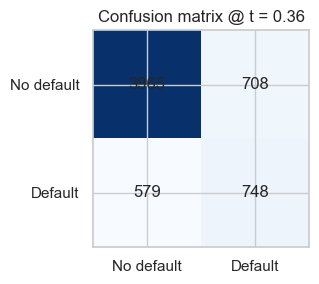

In [5]:
#plot confusion matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize = (4, 3))
plt.imshow(cm, cmap = "Blues")
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, f"{v}", ha = "center", va = "center", fontsize = 12)
plt.xticks([0, 1], ["No default", "Default"])
plt.yticks([0, 1], ["No default", "Default"])
plt.title(f"Confusion matrix @ t = {thr:.2f}")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi = 300)
plt.show()

Brier score: 0.141


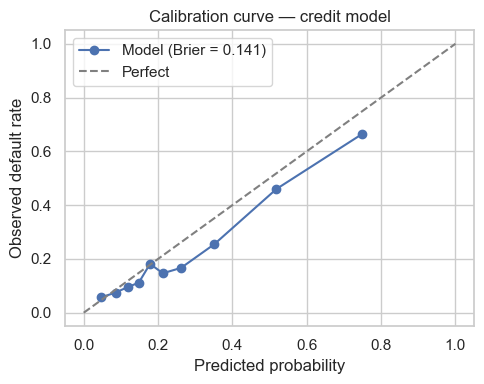

In [6]:
#calibration curve (probability reliability)

prob_true, prob_pred = calibration_curve(y_test, proba, n_bins = 10, strategy = "quantile")
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, proba)
print("Brier score:", round(brier,3))

plt.figure(figsize = (5,4))
plt.plot(prob_pred, prob_true, marker = "o", label = f"Model (Brier = {brier:.3f})")
plt.plot([0, 1], [0, 1], "--", color = "gray", label = "Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed default rate")
plt.title("Calibration curve — credit model")
plt.legend()
plt.tight_layout()
plt.savefig("images/calibration_curve.png", dpi = 300)
plt.show()

In [7]:
#SHAP — global explanations (summary bar + beeswarm)

#extract transformed feature names
pre = pipe.named_steps["pre"]
clf = pipe.named_steps["clf"]

ohe = pre.named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feat_names = num_cols + cat_names

len(feat_names), feat_names[:10]

(100,
 ['limit_bal',
  'age',
  'bill_amt1',
  'bill_amt2',
  'bill_amt3',
  'bill_amt4',
  'bill_amt5',
  'bill_amt6',
  'pay_amt1',
  'pay_amt2'])

Final sv_for_plot shape: (500, 100)


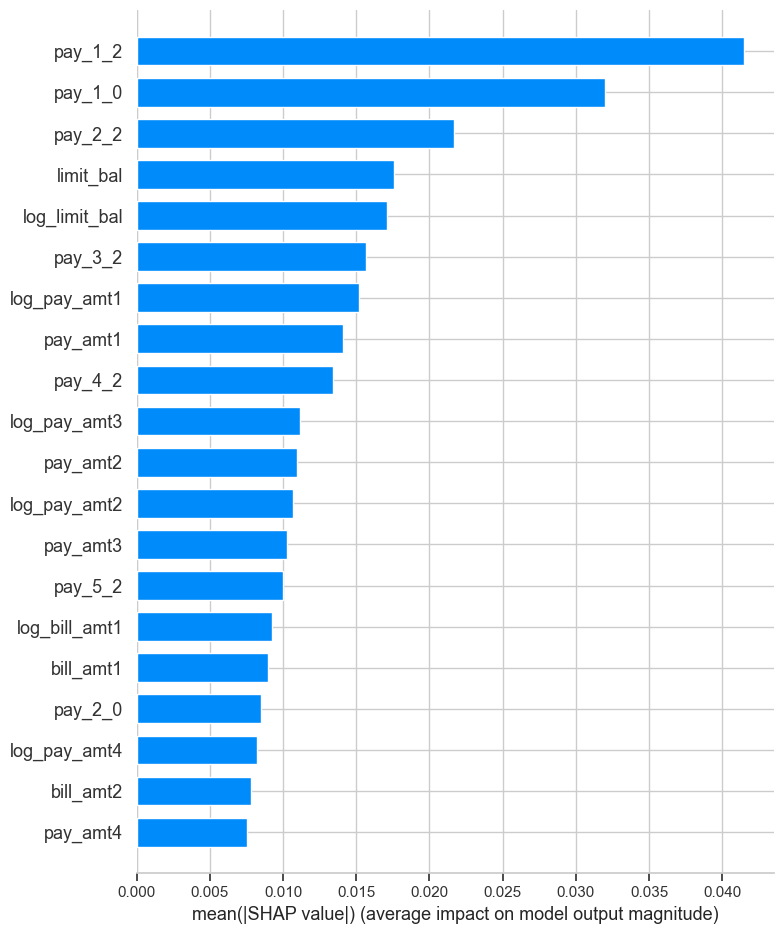

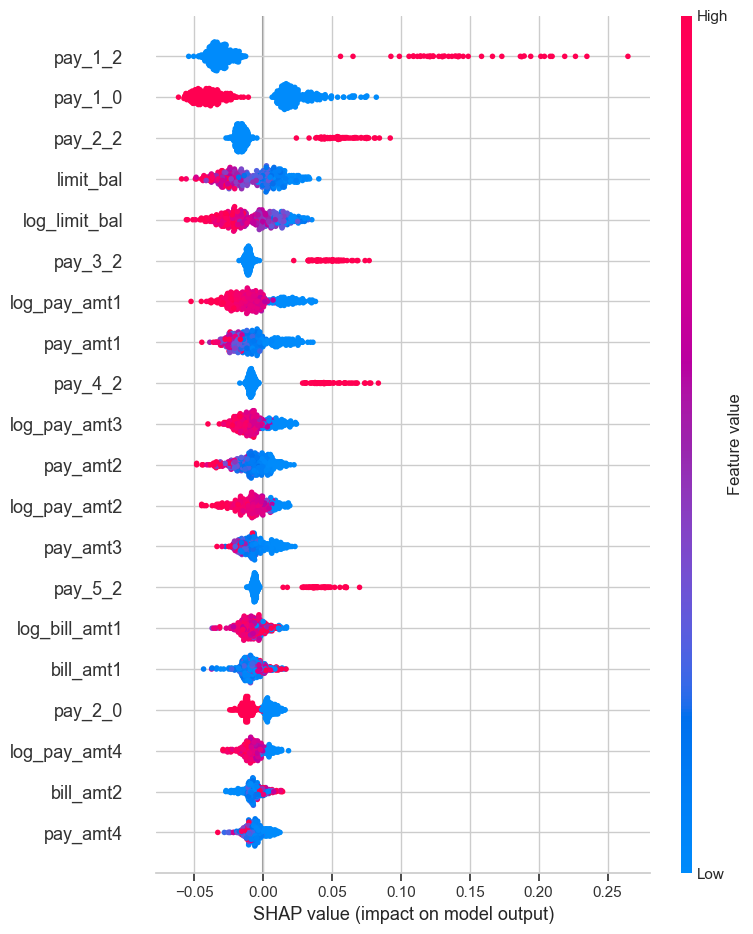

In [8]:
#transform X_test once for SHAP
Xte_trans = pre.transform(X_test)

idx = np.random.choice(len(X_test), size = 500, replace = False)
Xte_trans_small = Xte_trans[idx]
y_test_small = y_test.values[idx]

is_tree = (
    hasattr(clf, "estimators_")
    or clf.__class__.__name__.lower().startswith(("randomforest", "xgboost", "lightgbm"))
)

if is_tree:
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(Xte_trans_small)

    if isinstance(shap_values, list):
        sv_for_plot = shap_values[1]
    elif shap_values.ndim == 3 and shap_values.shape[-1] == 2:
        sv_for_plot = shap_values[:, :, 1]
    else:
        sv_for_plot = shap_values
else:
    explainer = shap.LinearExplainer(clf, Xte_trans_small, feature_dependence = "independent")
    sv_for_plot = explainer.shap_values(Xte_trans_small)

print("Final sv_for_plot shape:", sv_for_plot.shape)  

#global feature importance (bar)
shap.summary_plot(
    sv_for_plot,
    Xte_trans_small,
    feature_names = feat_names,
    plot_type = "bar",
    show = False
)
plt.tight_layout()
plt.savefig("images/shap_summary_bar.png", dpi = 300, bbox_inches = "tight")
plt.show()

#beeswarm (direction + magnitude)
shap.summary_plot(
    sv_for_plot,
    Xte_trans_small,
    feature_names = feat_names,
    show = False
)
plt.tight_layout()
plt.savefig("images/shap_summary_beeswarm.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [9]:
#SHAP — dependence plots for top features

#rank features by mean |SHAP|
mean_abs = np.abs(sv_for_plot).mean(axis = 0)
top_idx = np.argsort(-mean_abs)[:5]
top_feats = [feat_names[i] for i in top_idx]
top_feats

['pay_1_2', 'pay_1_0', 'pay_2_2', 'limit_bal', 'log_limit_bal']

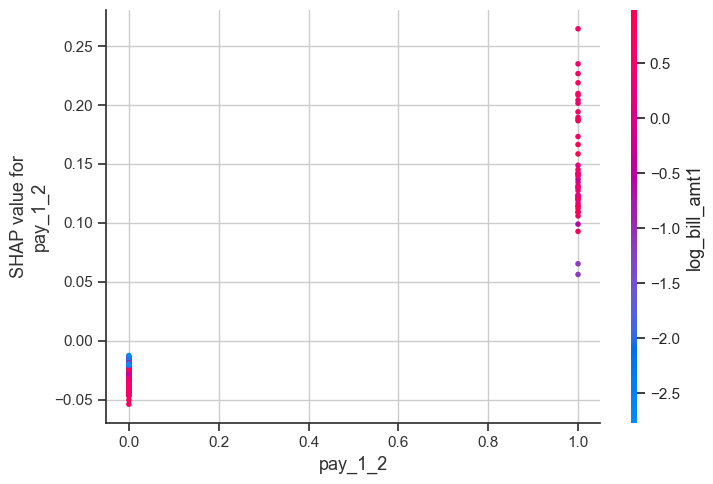

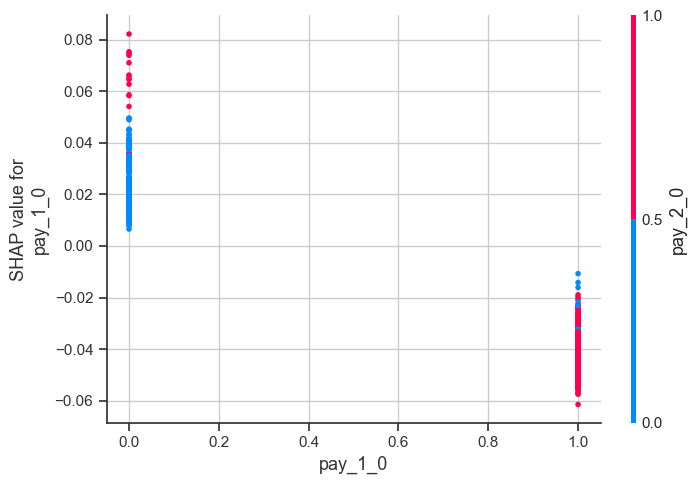

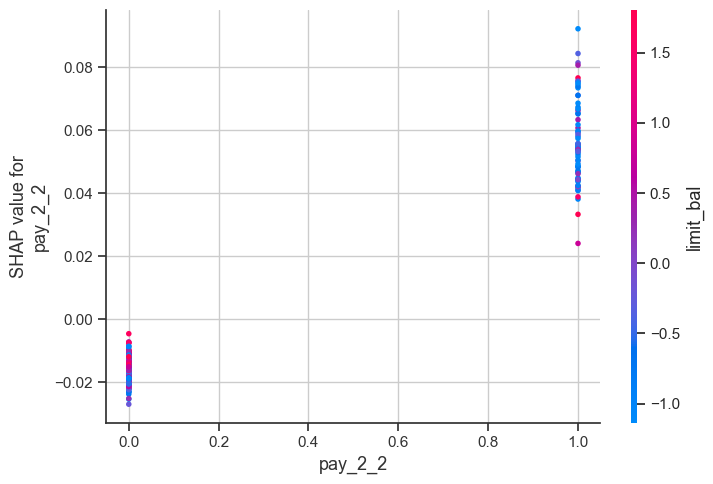

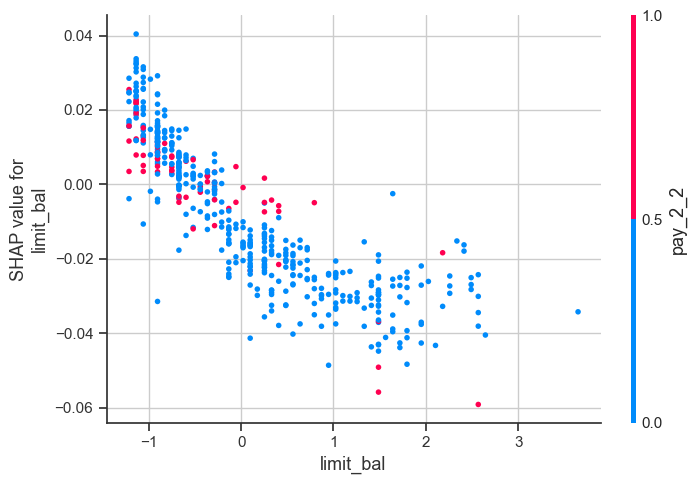

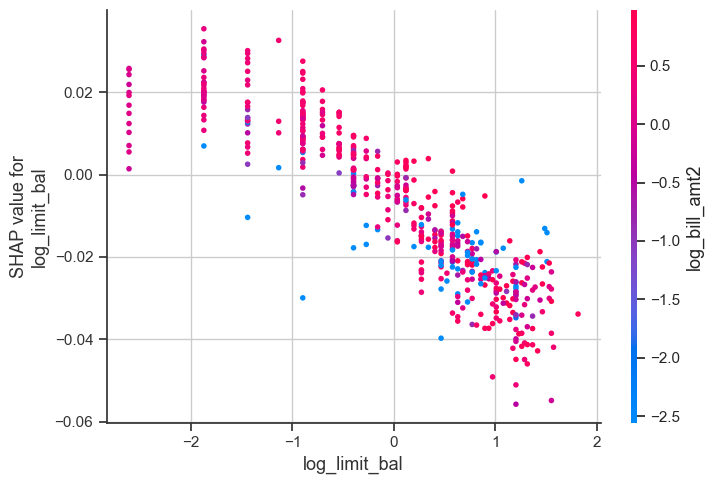

In [10]:
#dependence plots for top drivers
for f in top_feats:
    shap.dependence_plot(
        f,
        sv_for_plot,          
        Xte_trans_small,     
        feature_names = feat_names,
        show = False
    )
    safe = f.replace("/", "_").replace(" ", "_")
    plt.tight_layout()
    plt.savefig(f"images/shap_dependence_{safe}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

In [11]:
#SHAP global importance table

shap_importance = (
    pd.DataFrame({
        "feature": feat_names,
        "mean_abs_shap": np.abs(sv_for_plot).mean(axis = 0)
    })
    .sort_values("mean_abs_shap", ascending = False)
)

os.makedirs("models/artifacts", exist_ok = True)
shap_importance.to_csv("models/artifacts/feature_importance_shap.csv", index = False)
shap_importance.head(10)

,feature,mean_abs_shap
40,pay_1_2,0.041455
38,pay_1_0,0.032009
51,pay_2_2,0.021705
0,limit_bal,0.017549
14,log_limit_bal,0.017098
62,pay_3_2,0.015651
21,log_pay_amt1,0.015222
8,pay_amt1,0.014096
73,pay_4_2,0.013434
23,log_pay_amt3,0.011185


In [18]:
shap_importance.head(20)

,feature,mean_abs_shap
40,pay_1_2,0.041455
38,pay_1_0,0.032009
51,pay_2_2,0.021705
0,limit_bal,0.017549
14,log_limit_bal,0.017098
62,pay_3_2,0.015651
21,log_pay_amt1,0.015222
8,pay_amt1,0.014096
73,pay_4_2,0.013434
23,log_pay_amt3,0.011185


Chosen indices: [225, 1078, 2630, 4566]
sv_local shape: (4, 100)


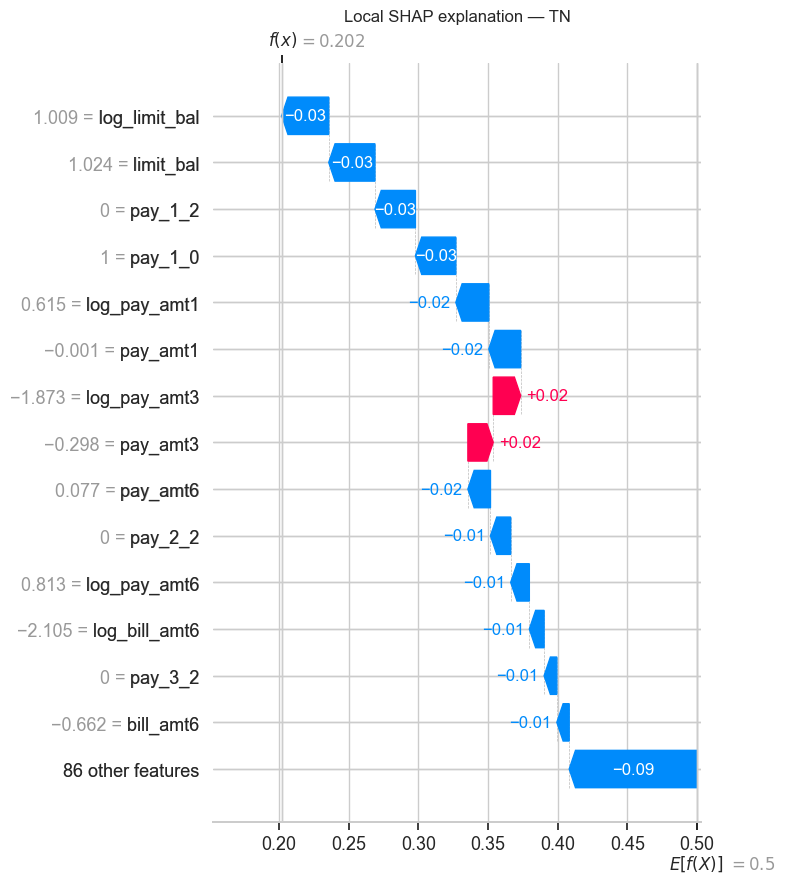

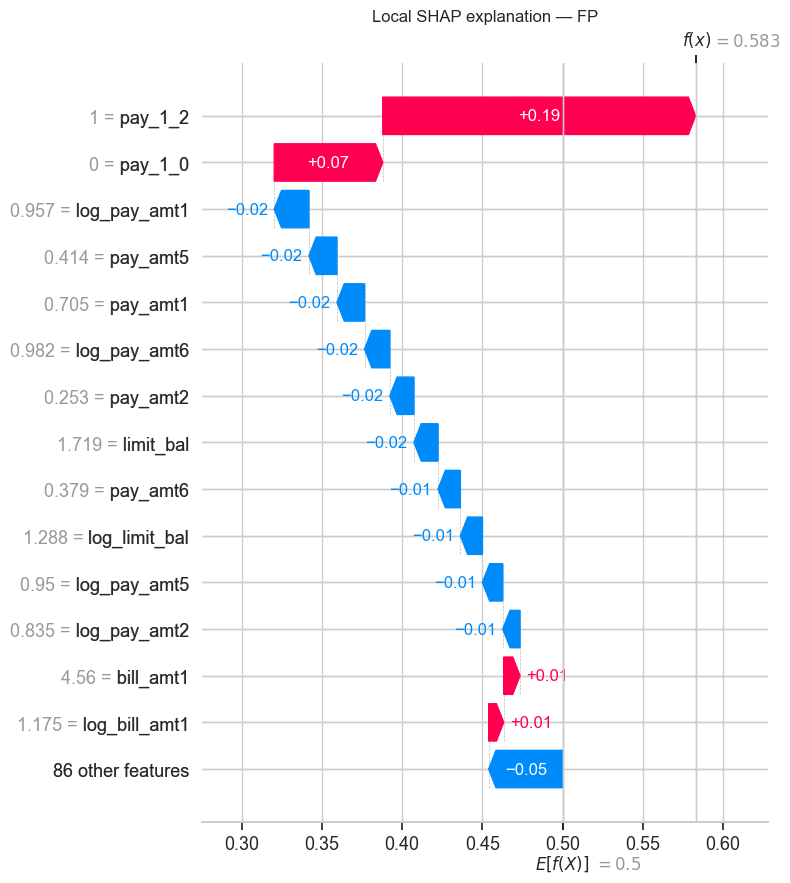

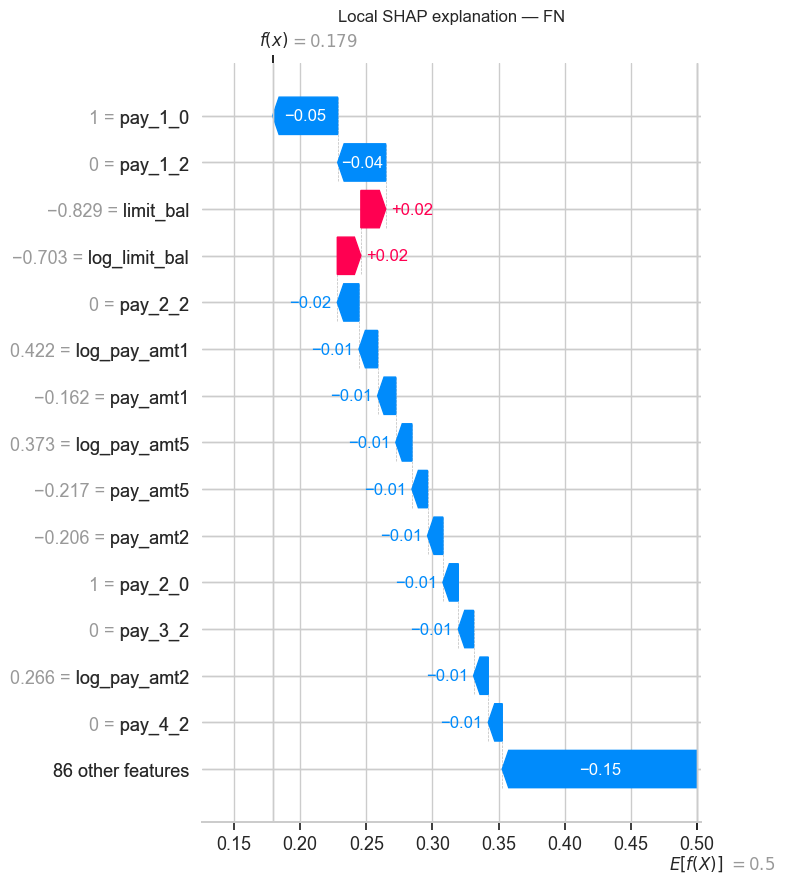

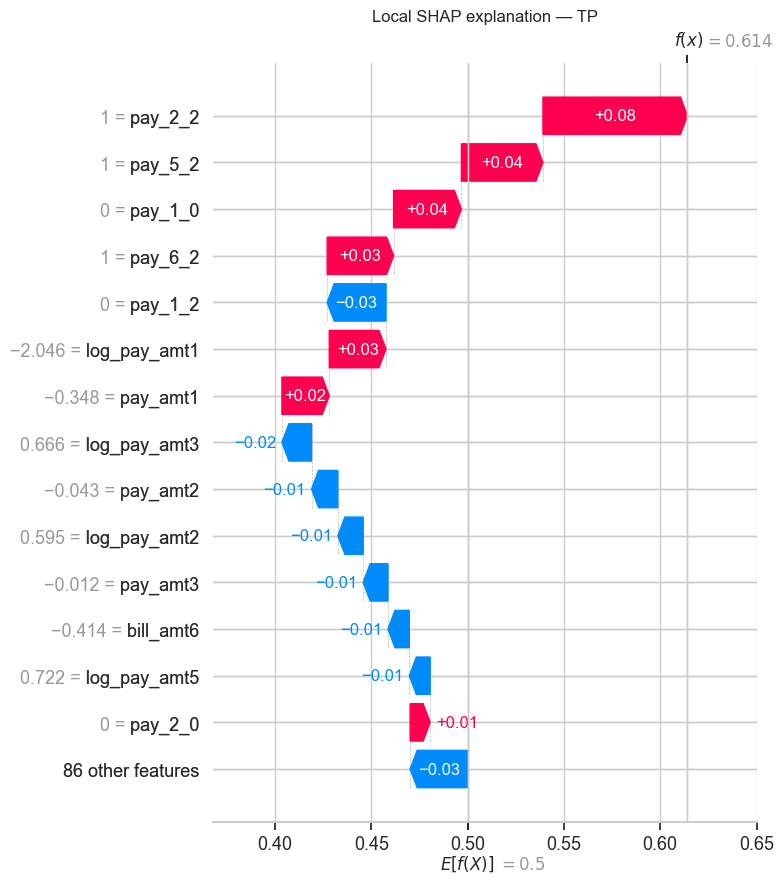

In [12]:
#SHAP local explanations: TP / FP / FN / TN

#build small dataframe to pick TP / FP / FN / TN
proba_test = proba            
pred_test  = (proba_test >= thr).astype(int)

cm_df = pd.DataFrame({
    "row":   np.arange(len(y_test)),
    "y":     y_test.values,
    "proba": proba_test,
    "pred":  pred_test,
})

def pick_one(mask, name):
    sub = cm_df[mask]
    if len(sub) == 0:
        print(f"No examples for {name}")
        return None
    return sub.sample(1, random_state = RANDOM_STATE)["row"].iloc[0]

idx_tn = pick_one((cm_df.y == 0) & (cm_df.pred == 0), "TN")
idx_fp = pick_one((cm_df.y == 0) & (cm_df.pred == 1), "FP")
idx_fn = pick_one((cm_df.y == 1) & (cm_df.pred == 0), "FN")
idx_tp = pick_one((cm_df.y == 1) & (cm_df.pred == 1), "TP")

picked = [i for i in [idx_tn, idx_fp, idx_fn, idx_tp] if i is not None]
print("Chosen indices:", picked)

if len(picked) == 0:
    print("No examples to explain; aborting local SHAP.")
else:
    #take only these rows for SHAP
    X_local = X_test.iloc[picked]
    X_local_trans = pre.transform(X_local)

    #compute SHAP only for these rows 
    if is_tree:
        shap_values_local = explainer.shap_values(X_local_trans, check_additivity = False)
        if isinstance(shap_values_local, list):
            sv_local = shap_values_local[1]
            base_value = explainer.expected_value[1]
        elif shap_values_local.ndim == 3 and shap_values_local.shape[-1] == 2:
            sv_local = shap_values_local[:, :, 1]
            base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
        else:
            sv_local = shap_values_local
            base_value = explainer.expected_value
    else:
        shap_values_local = explainer.shap_values(X_local_trans)
        sv_local = shap_values_local
        base_value = explainer.expected_value

    print("sv_local shape:", sv_local.shape)   

    #helper for robust waterfall plotting
    def plot_waterfall_idx(local_pos, label, save_path = None, max_display = 15):
        shap_vals_row = sv_local[local_pos]
        data_row = X_local_trans[local_pos]

        try:
            exp = shap.Explanation(
                values = shap_vals_row,
                base_values = base_value,
                data = data_row,
                feature_names = feat_names,
            )
            shap.plots.waterfall(exp, max_display = max_display, show = False)
        except Exception:
            shap.plots._waterfall.waterfall_legacy(
                base_value,
                shap_vals_row,
                feature_names = feat_names,
                max_display = max_display,
                show = False,
            )
        plt.title(f"Local SHAP explanation — {label}")
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi = 300, bbox_inches = "tight")
        plt.show()

    #map global row index -> local position in X_local
    row_to_local = {global_idx: i for i, global_idx in enumerate(picked)}

    os.makedirs("images/local", exist_ok = True)

    for global_idx, label in [(idx_tn, "TN"), (idx_fp, "FP"),
                              (idx_fn, "FN"), (idx_tp, "TP")]:
        if global_idx is not None:
            local_pos = row_to_local[global_idx]
            plot_waterfall_idx(
                local_pos,
                label = label,
                save_path = f"images/local/shap_local_{label}.png",
            )

Top features in raw space: ['limit_bal', 'log_limit_bal']
Using for PDP: ['limit_bal', 'age', 'bill_amt1']


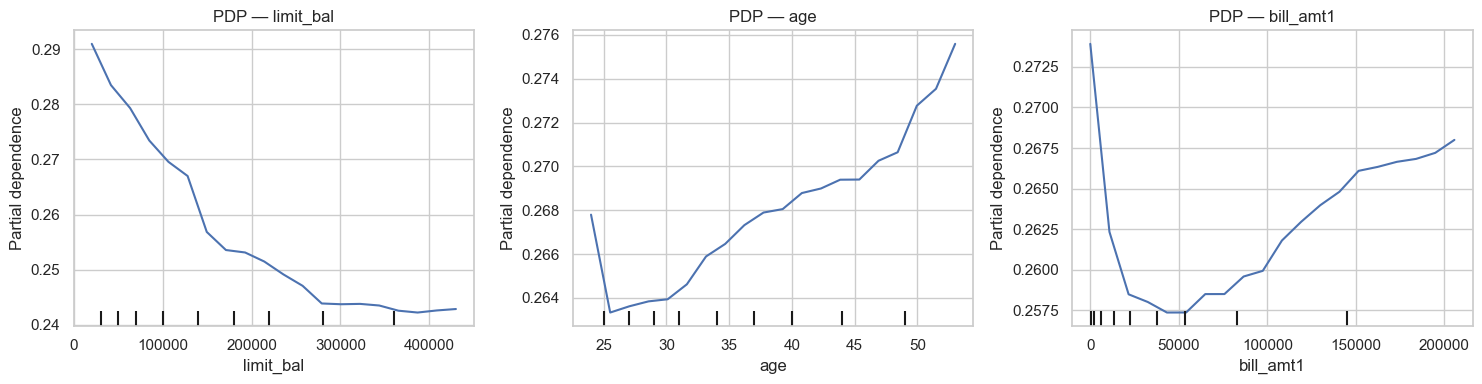

In [13]:
#partial dependence plots for key raw features

raw_cols = list(X.columns)
top_raw_feats = [f for f in top_feats if f in raw_cols]

print("Top features in raw space:", top_raw_feats)

#if not enough overlap, pick some manually
if len(top_raw_feats) < 3:
    fallback = ["limit_bal", "age", "bill_amt1", "pay_1"]
    top_raw_feats = [f for f in fallback if f in raw_cols]

top_raw_feats = top_raw_feats[:3]  
print("Using for PDP:", top_raw_feats)

fig, ax = plt.subplots(1, len(top_raw_feats), figsize = (5*len(top_raw_feats), 4))

if len(top_raw_feats) == 1:
    ax = [ax]

for i, feat in enumerate(top_raw_feats):
    PartialDependenceDisplay.from_estimator(
        pipe, X_test, features = [feat], kind = "average",
        grid_resolution = 20, ax = ax[i]
    )
    ax[i].set_title(f"PDP — {feat}")

plt.tight_layout()
plt.savefig("images/pdp_top_raw_features.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [15]:
#textual top-contributor explanation for selected customers 

def explain_local_instance(global_row_idx, top_n = 5):
    """Return top positive and negative SHAP drivers for a chosen customer."""

    if global_row_idx not in row_to_local:
        raise ValueError("This row was not included in SHAP local subset.")

    local_pos = row_to_local[global_row_idx]     
    shap_vals = sv_local[local_pos]             
    feats = np.array(feat_names)

    df_expl = (
        pd.DataFrame({
            "feature": feats,
            "shap_value": shap_vals
        })
        .sort_values("shap_value", ascending = False)
    )

    top_pos = df_expl.head(top_n)
    top_neg = df_expl.tail(top_n).sort_values("shap_value")

    return top_pos, top_neg


#choose one customer
example_idx = idx_tp if idx_tp is not None else picked[0]

top_pos, top_neg = explain_local_instance(example_idx, top_n = 5)

print("Explaining global row index:", example_idx)

print("\nTop 5 risk-increasing drivers (positive SHAP):")
display(top_pos)

print("\nTop 5 risk-decreasing drivers (negative SHAP):")
display(top_neg)

Explaining global row index: 4566

Top 5 risk-increasing drivers (positive SHAP):


,feature,shap_value
51,pay_2_2,0.075030
83,pay_5_2,0.042336
38,pay_1_0,0.035187
93,pay_6_2,0.034490
21,log_pay_amt1,0.029460



Top 5 risk-decreasing drivers (negative SHAP):


,feature,shap_value
40,pay_1_2,-0.030548
23,log_pay_amt3,-0.015389
9,pay_amt2,-0.013642
22,log_pay_amt2,-0.013158
10,pay_amt3,-0.012862
